In [1]:
import cv2
import numpy as np

from matplotlib import pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
RESIZE_TO=640
SCALE = 1.1
image_path1 = '../../../datasets/KITTI/dataset/valid_example/images/003930.png'
image_path2 = '../../../datasets/KITTI/dataset/valid_example/images/006934.png'
image_path3 = '../../../datasets/KITTI/dataset/valid_example/images/000854.png'
image_path4 = '../../../datasets/KITTI/dataset/valid_example/images/005554.png'

# Load an image using OpenCV
image1 = cv2.imread(image_path1)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
# Load an image using OpenCV
image2 = cv2.imread(image_path2)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
# Load an image using OpenCV
image3 = cv2.imread(image_path3)
image3 = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
# Load an image using OpenCV
image4 = cv2.imread(image_path4)
image4 = cv2.cvtColor(image4, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

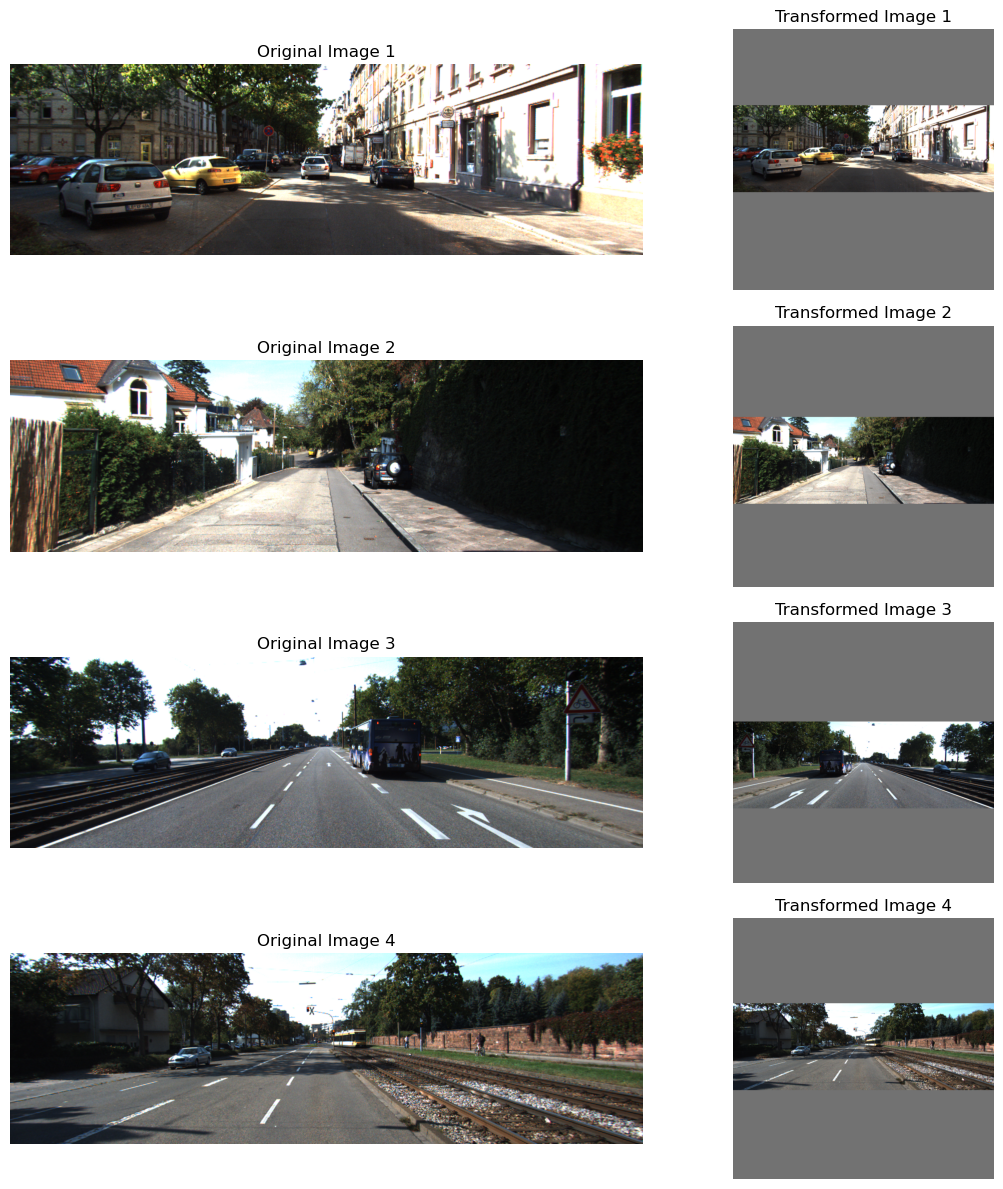

In [13]:
SCALE = 1.10

transform = A.Compose([
    A.LongestMaxSize(max_size=int(RESIZE_TO * SCALE)),

    A.PadIfNeeded(
        min_height=int(RESIZE_TO * SCALE),
        min_width=int(RESIZE_TO * SCALE),
        border_mode=cv2.BORDER_CONSTANT,
        value=(114, 114, 114)
    ),

    A.RandomCrop(
        width=RESIZE_TO,
        height=RESIZE_TO,
    ),

    A.ShiftScaleRotate(
        rotate_limit=5,
        scale_limit=0.03,
        shift_limit=0.03,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=(114, 114, 114)
    ),

    A.HorizontalFlip(p=0.5),

    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
])

transformed1 = transform(image=image1)
image_transformed1 = transformed1['image']

transformed2 = transform(image=image2)
image_transformed2 = transformed2['image']

transformed3 = transform(image=image3)
image_transformed3 = transformed3['image']

transformed4 = transform(image=image4)
image_transformed4 = transformed4['image']


fig, axes = plt.subplots(4, 2, figsize=(12, 12))

images = [image1, image2, image3, image4]
transformed_images = [
    image_transformed1,
    image_transformed2,
    image_transformed3,
    image_transformed4,
]

for i in range(4):

    # Original
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')

    # Transformed
    img_t = transformed_images[i]

    # tensor -> numpy fix (Albumentations)
    if hasattr(img_t, "permute"):
        img_t = img_t.permute(1,2,0).cpu().numpy()

    axes[i, 1].imshow(img_t)
    axes[i, 1].set_title(f'Transformed Image {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()